# Lending Club Credit Risk Analysis
## Modelling — Logistic Regression → Random Forest → XGBoost

**Objective:** Train and compare three models of increasing complexity on our 
engineered feature set. Evaluate using metrics that matter in credit risk:
AUC-ROC, Gini Coefficient, and Precision-Recall AUC.

**Modelling philosophy:**
- Start simple (Logistic Regression) to establish an interpretable baseline
- Add complexity only where it demonstrably improves performance
- Never optimise for accuracy alone, class imbalance makes it misleading

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline
import xgboost as xgb

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.facecolor": "white",
})

FIGURES_DIR = "../reports/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("✓ Libraries loaded")

✓ Libraries loaded


In [8]:
df = pd.read_parquet("../data/processed/model_ready.parquet")

X = df.drop(columns=['default'])
y = df['default']

print(f"✓ Dataset loaded: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"✓ Default rate:   {y.mean():.2%}")

✓ Dataset loaded: 1,345,310 rows × 43 features
✓ Default rate:   19.96%


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserve class balance in both splits
)

print(f"Training set:  {X_train.shape[0]:,} loans")
print(f"Test set:      {X_test.shape[0]:,} loans")
print(f"Train default rate: {y_train.mean():.2%}")
print(f"Test default rate:  {y_test.mean():.2%}")

Training set:  1,076,248 loans
Test set:      269,062 loans
Train default rate: 19.96%
Test default rate:  19.96%


---
## Helper: Evaluation Function

We define a single evaluation function used consistently across all three models.
This ensures fair comparison. Every model is judged on identical metrics.

**Gini Coefficient** = 2 × AUC − 1. This is the standard performance metric 
in credit risk (not accuracy). A Gini of 0 means the model is random; 
1.0 means perfect. Industry models typically achieve 0.40–0.65.

In [10]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train, predict, and return a results dict with all key metrics."""
    
    start = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - start
    
    y_prob = model.predict_proba(X_te)[:, 1]
    
    auc    = roc_auc_score(y_te, y_prob)
    gini   = 2 * auc - 1
    pr_auc = average_precision_score(y_te, y_prob)
    
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  AUC-ROC:       {auc:.4f}")
    print(f"  Gini:          {gini:.4f}")
    print(f"  PR-AUC:        {pr_auc:.4f}")
    print(f"  Training time: {elapsed:.1f}s")
    
    return {
        "name":    name,
        "model":   model,
        "y_prob":  y_prob,
        "auc":     auc,
        "gini":    gini,
        "pr_auc":  pr_auc,
        "elapsed": elapsed,
    }

print("✓ Evaluation function defined")

✓ Evaluation function defined


---
## Model 1: Logistic Regression (Baseline)

Linear model with L2 regularisation. Interpretable, fast, and a strong 
baseline for tabular credit data. We scale features first. Logistic 
regression is sensitive to feature magnitude.

`class_weight='balanced'` corrects for the 80/20 class imbalance 
without resampling.

In [11]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                   class_weight='balanced',
                   max_iter=1000,
                   random_state=42,
                   n_jobs=-1
               ))
])

results_lr = evaluate_model(
    "Logistic Regression",
    lr_pipeline,
    X_train, y_train,
    X_test,  y_test
)


  Logistic Regression
  AUC-ROC:       0.7081
  Gini:          0.4163
  PR-AUC:        0.3692
  Training time: 12.4s


---
## Model 2: Random Forest

Ensemble of decision trees that handles non-linearities and feature 
interactions automatically. No scaling needed. We use 300 trees, enough to stabilise performance without excessive training time.

In [6]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

results_rf = evaluate_model(
    "Random Forest",
    rf_model,
    X_train, y_train,
    X_test,  y_test
)


  Random Forest
  AUC-ROC:       0.7115
  Gini:          0.4230
  PR-AUC:        0.3758
  Training time: 451.9s


---
## Model 3: XGBoost

Gradient boosted trees, typically the best performer on structured 
tabular data. Handles missing values natively, highly regularised, 
and fast with GPU support. This is our production candidate.

`scale_pos_weight` handles class imbalance for XGBoost specifically:
it's set to the ratio of negative to positive class counts.

In [12]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos:.2f}  (ratio of non-defaults to defaults)")

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

results_xgb = evaluate_model(
    "XGBoost",
    xgb_model,
    X_train, y_train,
    X_test,  y_test
)

scale_pos_weight: 4.01  (ratio of non-defaults to defaults)

  XGBoost
  AUC-ROC:       0.7213
  Gini:          0.4426
  PR-AUC:        0.3903
  Training time: 93.6s


---
## Model Comparison

Side-by-side comparison of all three models across every metric.
#### Comparaison Table

In [13]:
results_all = [results_lr, results_rf, results_xgb]

comparison = pd.DataFrame([{
    "Model":         r["name"],
    "AUC-ROC":       round(r["auc"],    4),
    "Gini":          round(r["gini"],   4),
    "PR-AUC":        round(r["pr_auc"], 4),
    "Training Time": f"{r['elapsed']:.1f}s"
} for r in results_all])

print(comparison.to_string(index=False))

              Model  AUC-ROC   Gini  PR-AUC Training Time
Logistic Regression   0.7081 0.4163  0.3692         12.4s
      Random Forest   0.7115 0.4230  0.3758        451.9s
            XGBoost   0.7213 0.4426  0.3903         93.6s


#### ROC Curve (All Three Models)

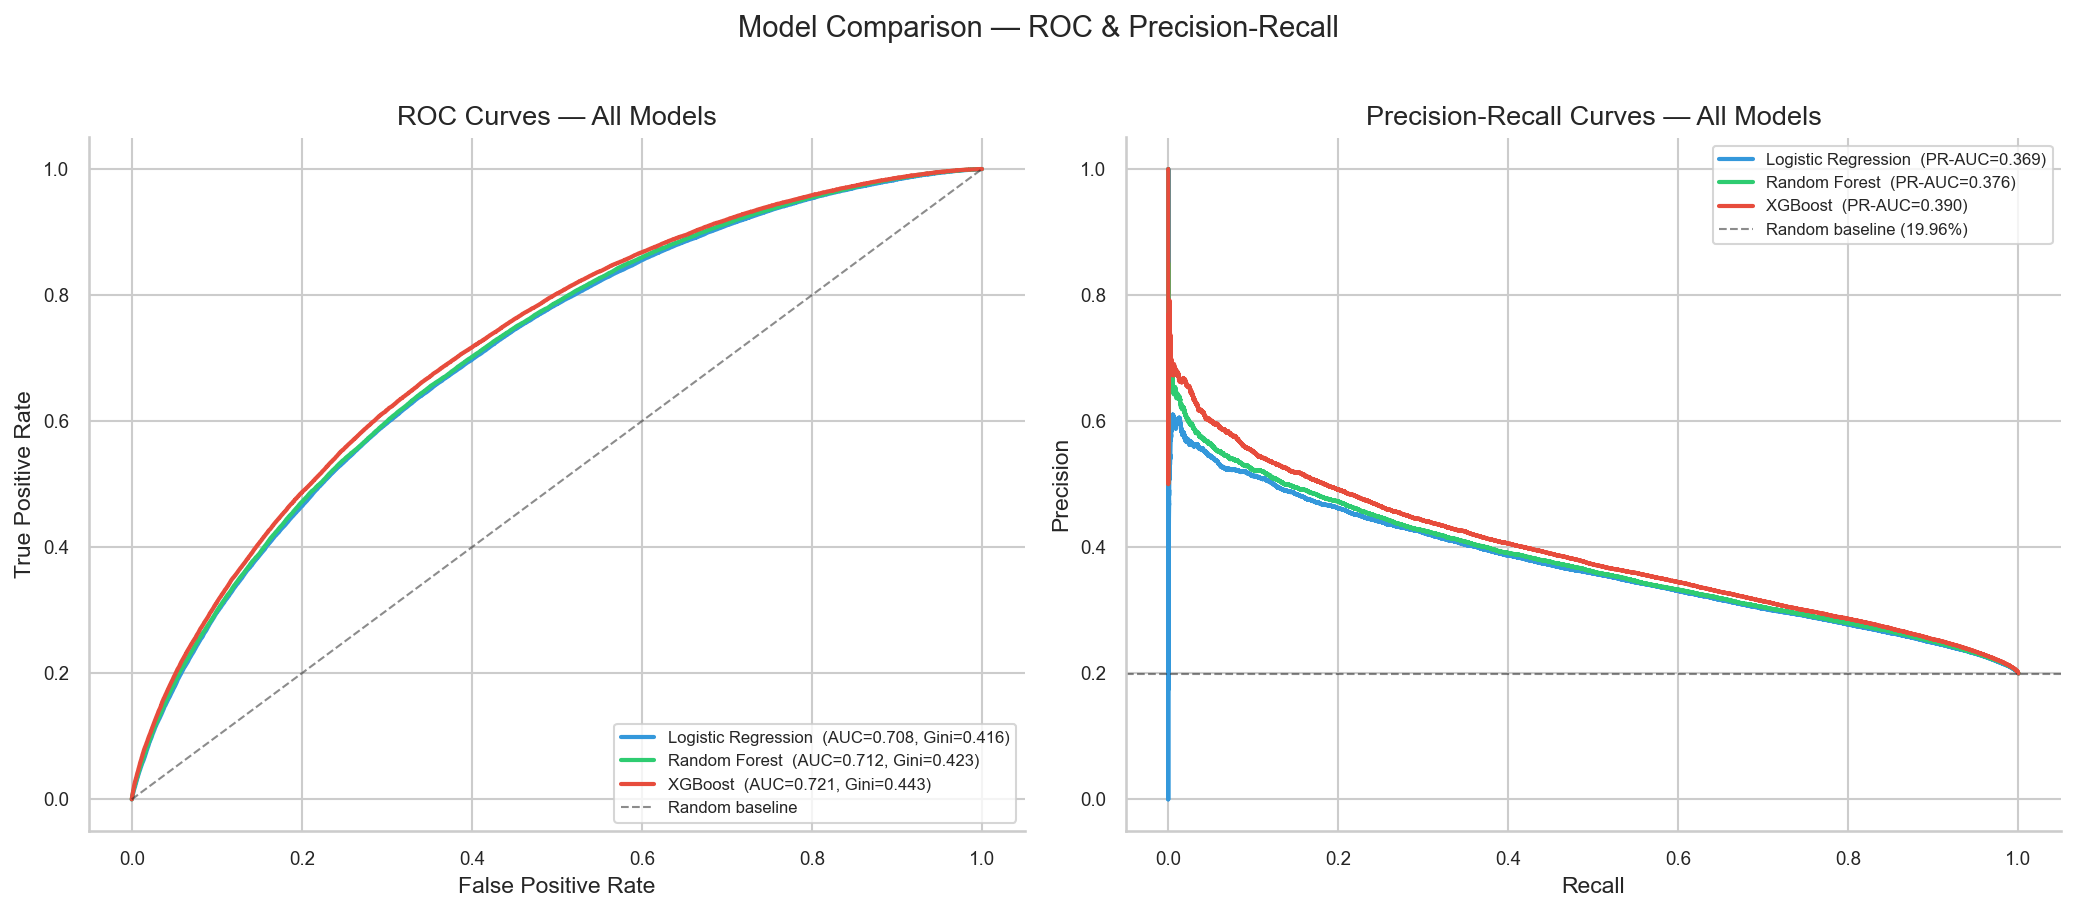

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#3498db', '#2ecc71', '#e74c3c']

# ── Left: ROC curves ───────────────────────────────────────────────────────────
for r, color in zip(results_all, colors):
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{r['name']}  (AUC={r['auc']:.3f}, Gini={r['gini']:.3f})")

axes[0].plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5, label='Random baseline')
axes[0].set_title("ROC Curves — All Models")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8, loc='lower right')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Right: Precision-Recall curves ────────────────────────────────────────────
for r, color in zip(results_all, colors):
    prec, rec, _ = precision_recall_curve(y_test, r["y_prob"])
    axes[1].plot(rec, prec, color=color, linewidth=2,
                 label=f"{r['name']}  (PR-AUC={r['pr_auc']:.3f})")

baseline = y_test.mean()
axes[1].axhline(baseline, color='k', linestyle='--', linewidth=1,
                alpha=0.5, label=f'Random baseline ({baseline:.2%})')
axes[1].set_title("Precision-Recall Curves — All Models")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8, loc='upper right')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle("Model Comparison — ROC & Precision-Recall", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}08_roc_pr_curves.png", bbox_inches='tight')
plt.show()

#### Feature Importance (XG Boost)

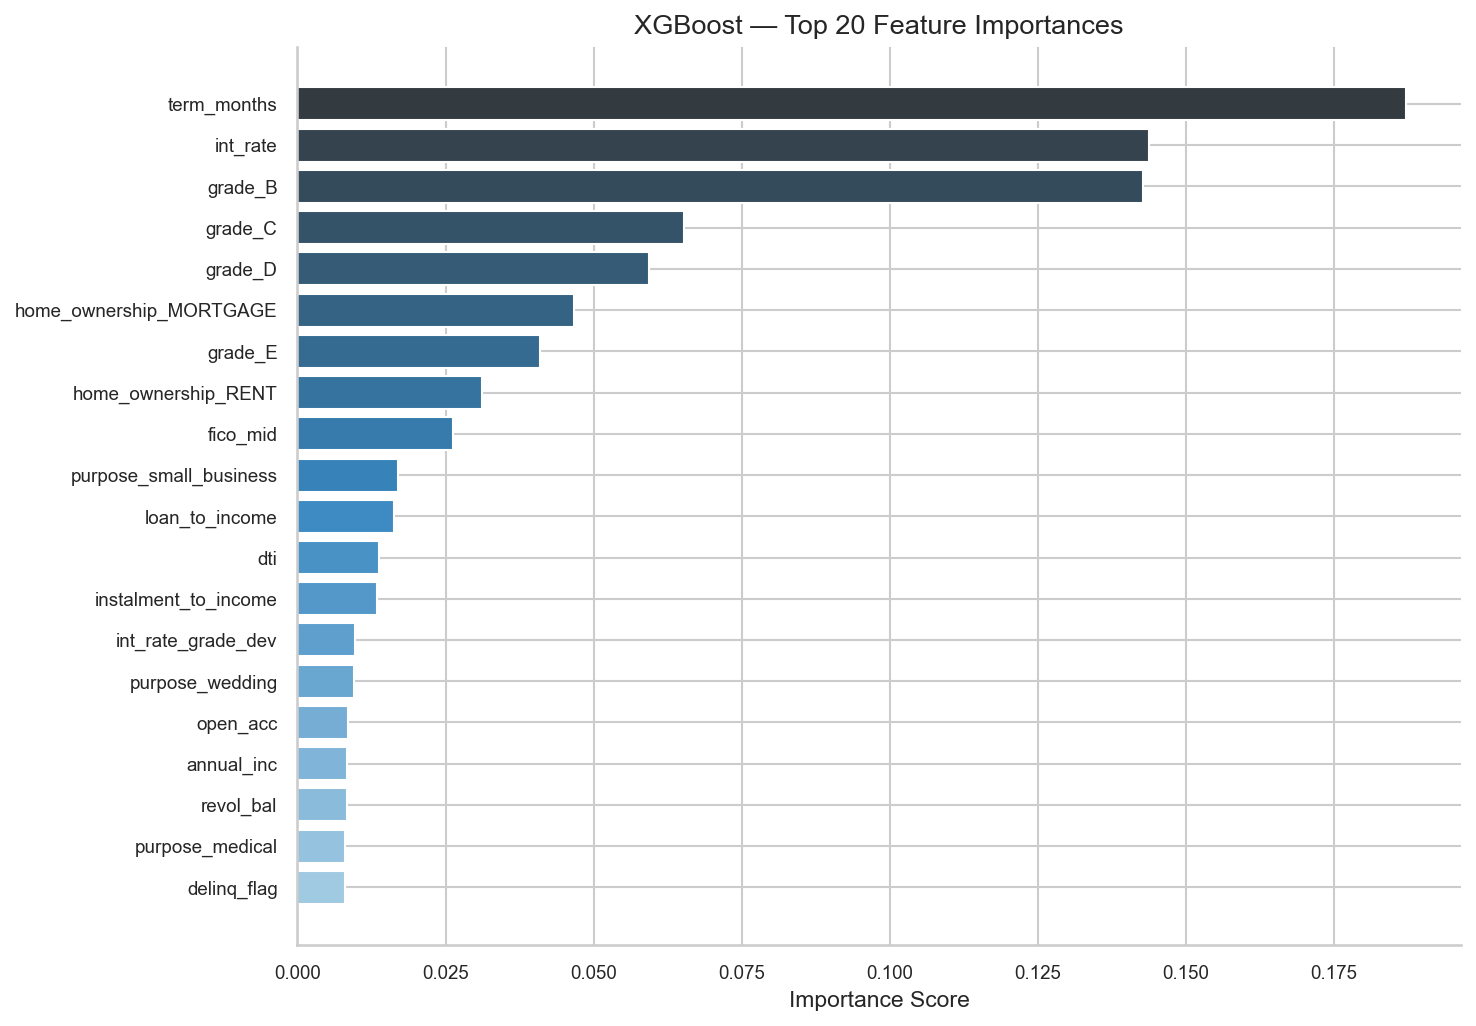


Top 10 features:
term_months                0.187058
int_rate                   0.143706
grade_B                    0.142757
grade_C                    0.065244
grade_D                    0.059352
home_ownership_MORTGAGE    0.046631
grade_E                    0.040995
home_ownership_RENT        0.031156
fico_mid                   0.026324
purpose_small_business     0.016905


In [15]:
importances = pd.Series(
    results_xgb["model"].feature_importances_,
    index=X_train.columns
).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("Blues_d", len(importances))
ax.barh(importances.index, importances.values, color=colors)
ax.set_title("XGBoost — Top 20 Feature Importances", fontsize=13)
ax.set_xlabel("Importance Score")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}09_xgb_feature_importance.png", bbox_inches='tight')
plt.show()

print("\nTop 10 features:")
print(importances.tail(10).sort_values(ascending=False).to_string())

#### Probability Distribution by Outcome

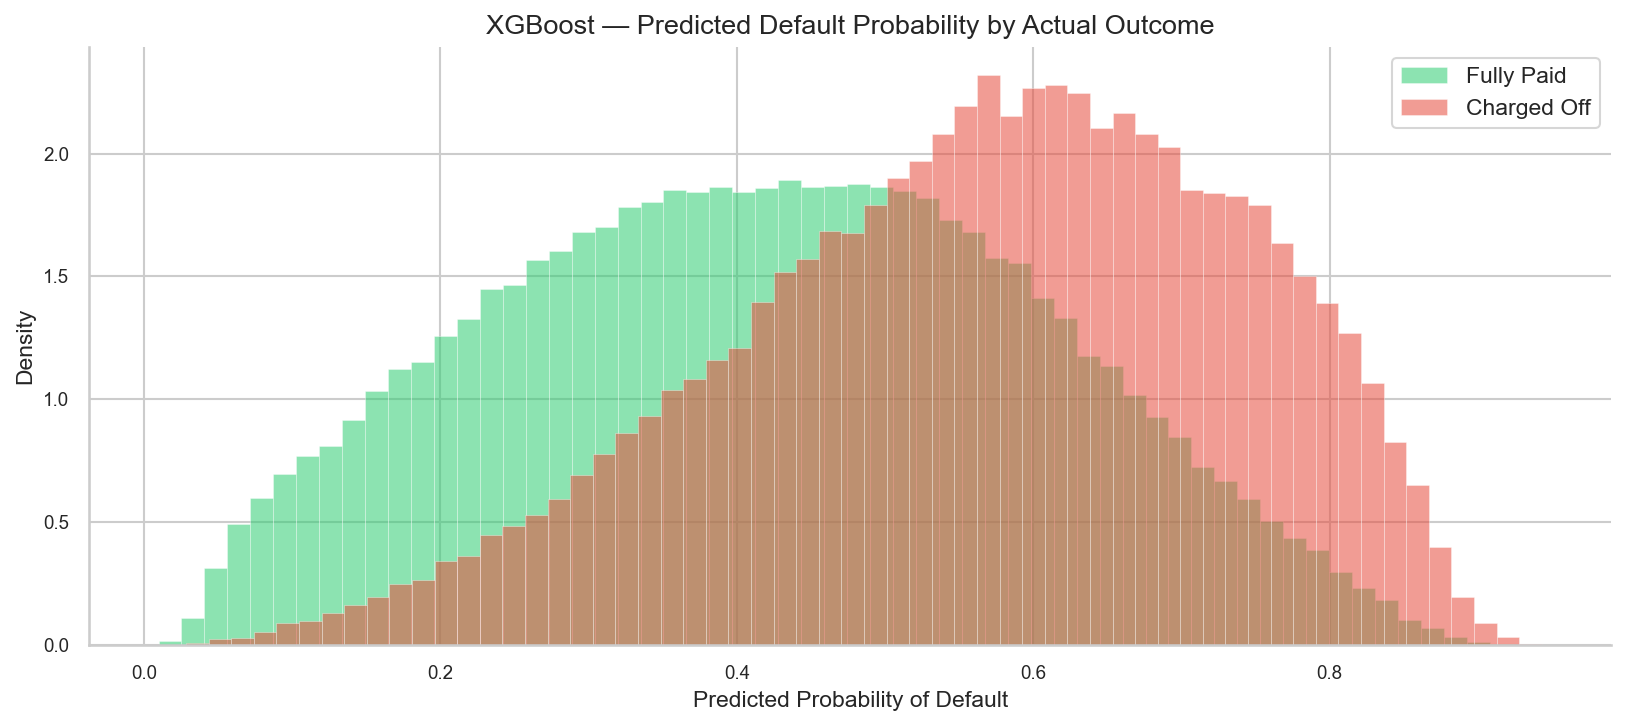

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))

for label, mask, color in [
    ('Fully Paid',  y_test == 0, '#2ecc71'),
    ('Charged Off', y_test == 1, '#e74c3c')
]:
    ax.hist(results_xgb["y_prob"][mask], bins=60, alpha=0.55,
            density=True, color=color, label=label,
            edgecolor='white', linewidth=0.3)

ax.set_title("XGBoost — Predicted Default Probability by Actual Outcome", fontsize=13)
ax.set_xlabel("Predicted Probability of Default")
ax.set_ylabel("Density")
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}10_probability_distribution.png", bbox_inches='tight')
plt.show()

---
## Modelling Summary

|Model | AUC-ROC |  Gini | PR-AUC |
|------|---------|-------|--------|
|Logistic Regression |  0.7081 | 0.4163 | 0.3692 |
|Random Forest | 0.7115 | 0.4230 | 0.3758 |
|XGBoost | 0.7213 | 0.4426 | 0.3903 |


**Winner: XGBoost** has the highest Gini coefficient (0.4426) and strongest separation 
of defaulters from non-defaulters. Selected as the production candidate for 
interpretation and business simulation in notebook 04.

**Key insight from feature importance:** The model's top signals are loan term, 
interest rate, and loan grade are consistent with EDA findings and grounded in 
lending business logic. FICO score appears independently of grade, confirming 
it carries signal beyond Lending Club's own risk tier assignment.

**Next:** `04_model_interpretation.ipynb`: SHAP values, credit scorecard, 
and business simulation.

In [17]:
import joblib
os.makedirs("../models/", exist_ok=True)

joblib.dump(results_xgb["model"], "../models/xgb_model.pkl")
joblib.dump(results_lr["model"],  "../models/lr_model.pkl")

saved_figs = sorted(os.listdir(FIGURES_DIR))
print(f"✓ {len(saved_figs)} figures in reports/figures/")
print(f"✓ Models saved to models/")
print(f"\nNew figures added this notebook:")
for f in saved_figs:
    if f.startswith(('08', '09', '10')):
        print(f"   {f}")

✓ 10 figures in reports/figures/
✓ Models saved to models/

New figures added this notebook:
   08_roc_pr_curves.png
   09_xgb_feature_importance.png
   10_probability_distribution.png
